## 决策树
简而言之，决策树其实就是通过一连串的“如果...则...”的规则，不断缩小数据类别可能的范围，最终确定它的类别（也可以是一个回归值）

我们可以来看下面这个案例：
> 我们想要判断今天出门是否合适，下面这个过程就可以用来确定最后的结果
```
外面下雨吗？
├── 是 → 风大吗？
│   ├── 是 → 不出去
│   └── 否 → 出去
└── 否 → 有太阳吗？
    ├── 是 → 出去
    └── 否 → 温度多少？
        ├── >20°C → 出去
        └── ≤20°C → 不出去

```
如上，这个判断过程写成流程图的形式很像是一颗大树，数据从最开始的树干（根节点）出发，经过一轮或多轮在分叉出来的树枝（分支节点）上的判断，最终到达树枝末端的特定叶片（叶子节点），确定输入量类别（或回归值）

决策树的训练，实际上就是更具过往知识（训练集）确定整棵“大树”的结构及参数的过程，其核心思想就是：

**递归地选择“最佳”特征和切分点，将数据集分成尽可能纯的子集**

如果还想要更深入的理解决策树的机制，就要理解“纯”的含义

这里的“纯”，反映的就是最终分进同一个类别里的数据要尽可能相似（这也是我们分类的目的）

为了来定量描述这个所谓的“纯”，我们将使用三种指标：
1. **基尼杂质（Gini impurity）**：衡量从集合中随机抽两个样本，它们类别不一样的概率。
$$\text{Gini}(D) = 1 - \sum_{k=1}^{K} p_k^2$$
2. **信息熵（Entropy）**：源自信息论，衡量不确定性的期望，此处要与信息增益配合
$$\text{Entropy}(D) = - \sum_{k=1}^{K} p_k \log_2 p_k$$
3. **信息增益（Information Gain）**：父亲节点的不纯度 减去 按某特征切分后子节点不纯度的加权和。该值越大，说明这次切分让数据变得更“纯”，效果越好。
$$\text{Gain}(D, A) = \text{Entropy}(D) - \sum_{v \in Values(A)} \frac{|D_v|}{|D|} \cdot \text{Entropy}(D_v)$$

其中，$D$ 为数据集，$p_k$ 是节点中第 $k$ 类样本的比例，$A$ 为候选特征，$D_v$ 为 $A$ 取为 $v$ 时的子集。

实际上，在实际的使用过程中，两者最终的效果一般不会由质上的差别，多数时候还会因为基尼杂质训练将快而使之成为首选

In [219]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

### **1.读取数据集并获得其基本信息**

In [220]:
df = pd.read_csv('train_and_test2.csv')
print(df.columns.tolist())

['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']


### **2.进行数据预处理**

#### 2.1 提取有效数据列并查看数据缺失情况

In [221]:
features_target = ['Age', 'Fare', 'Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked', '2urvived']
data = df[features_target]
nan = data.isnull().sum()
print(f'各特征列数据确实情况为：\n{nan}')

各特征列数据确实情况为：
Age         0
Fare        0
Sex         0
sibsp       0
Parch       0
Pclass      0
Embarked    2
2urvived    0
dtype: int64


#### 2.2 填充缺失数据

In [222]:
most_frequent_embarked = data['Embarked'].mode()[0]
data['Embarked'] = data['Embarked'].fillna(most_frequent_embarked, inplace = False)
data

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0
...,...,...,...,...,...,...,...,...
1304,28.0,8.0500,0,0,0,3,2.0,0
1305,39.0,108.9000,1,0,0,1,0.0,0
1306,38.5,7.2500,0,0,0,3,2.0,0
1307,28.0,8.0500,0,0,0,3,2.0,0


### **3.对数据集进行划分**

In [223]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

### **4.训练模型并进行预测**
关于训练，我们其实还有一些需要讨论的，那就是到底纯度到多纯净我们可以把他们归为一类？如果不做限制，树将无限制地长下去，它会记住所有训练数据的噪声，过拟合到极致（一片叶子一个样本）。所以必须“控制生长”，我们成这个过程为**剪枝**，通常有两种手段来实现：
1. **预剪枝**
2. **后剪枝**

#### 4.1 预剪枝（Pre-pruning）：划定边界，提前喊停
| sklearn 参数 | 作用              | 常用值                |
|-----------|-----------------|--------------------|
| `max_depth` | 树的最大深度          | 3~10，防过拟合头号利器      |
| `min_samples_split` | 节点最少样本数才继续分裂    | 5~20               |
| `min_samples_leaf` | 叶节点最少样本数        | 1~10               |
| `max_features` | 每次分裂时随机选用的特征数   | 由数据特征量决定           |
| `max_leaf_nodes` | 最大叶节点总数         | 5~50，不能太大，避免模型记住噪声 |
| `min_impurity_decrease` | 不纯度下降小于这个值就不分裂  | 0.001~0.01         |

In [224]:
base_tree = DecisionTreeClassifier(
    criterion = 'gini',   #或 'entropy'
    max_depth = 10,
    min_samples_split = 5,
    min_samples_leaf = 3,
    max_features = 5,
    random_state = 42
)
base_tree.fit(X_train, y_train)
y_pred = base_tree.predict(X_test)


#### 4.2 后剪枝（Post-pruning）：先长再砍

In [225]:
# 获取完全树的代价复杂度剪枝路径（获得一系列 alpha 值和对应的子树的叶子数、误差）
path = base_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas  # 候选的 alpha 值（从小到大）
impurities = path.impurities  # 对应 alpha 的误差变化

# 对每个 alpha 训练一棵剪枝后的树，并评估其在训练集和测试集上的表现
test_scores = []

# 注意：ccp_alphas 的最后一个值很大，可能使树只剩下根节点，我们通常不取最后一个
for alpha in ccp_alphas[:-1]:  # 去掉最后一个，避免给枝干全剪完了
    tree = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 10,
    min_samples_split = 5,
    min_samples_leaf = 3,
    max_features = 5,
    random_state = 42
    )
    base_tree.fit(X_train, y_train)
    tree.fit(X_train, y_train)
    test_scores.append(accuracy_score(y_test, tree.predict(X_test)))
best_alpha = ccp_alphas[:-1][np.argmax(test_scores)]
# 4. 得到最终模型
final_tree = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 10,
    min_samples_split = 5,
    min_samples_leaf = 3,
    max_features = 5,
    ccp_alpha = best_alpha,
    random_state = 42
)
final_tree.fit(X_train, y_train)
y_pred = final_tree.predict(X_test)

### 5.评估模型训练效果

In [226]:
# 混淆矩阵
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, y_pred)
print(cm)
TN, FP = cm[0, 0], cm[0, 1]
FN, TP = cm[1, 0], cm[1, 1]

[[161  21]
 [ 52  28]]


In [227]:
# accuracy, recall, precision, f1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.88      0.82       182
           1       0.57      0.35      0.43        80

    accuracy                           0.72       262
   macro avg       0.66      0.62      0.62       262
weighted avg       0.70      0.72      0.70       262



### **6.模型预测效果可视化**
用 ROC 曲线和混淆矩阵热力图这两张常用的指标图来直观评估模型效果

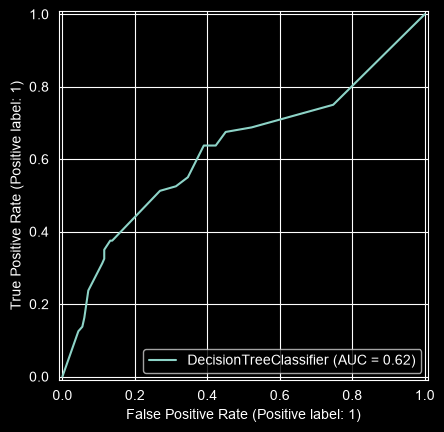

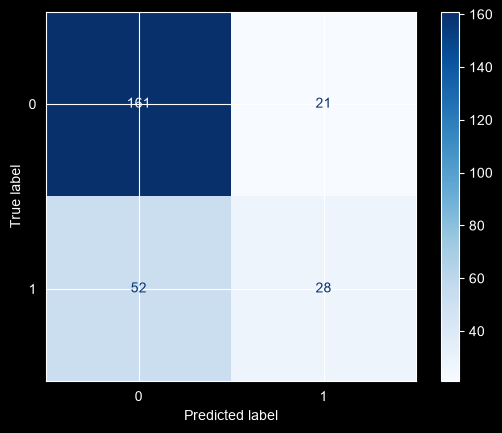

In [228]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# ROC 曲线
RocCurveDisplay.from_estimator(final_tree, X_test, y_test)
plt.show('lr_roc_curve.png')

# 混淆矩阵热力图
ConfusionMatrixDisplay.from_estimator(final_tree, X_test, y_test, cmap='Blues')
plt.show('lr_confusion_matrix.png')